<a href="https://colab.research.google.com/github/naz-picones/MO-IT128-DMP-A3107-Lucero-Picones-Ramos/blob/main/Revised_MO_IT128_Homework_Project_Clustering_and_Segmentation_BSIT_A3107_Lucero%2CC_J%2C_Ramos%2C_M_G%2C_Picones%2CM_N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Loading and Overview

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [166]:
df = pd.read_csv("FinMark_Final.csv")

display(df.head())
print(df.shape)
print(df.columns.tolist())

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Transaction_Type,Transaction_Amount_log,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend,month,Total_Spend,Avg_Transaction_Value,Transaction_Count,months_since_last_transaction,Transaction_Type_Encoded,total_spend_log
0,49,234,2023-01-03 00:00:00,1926.0,Investment,7.563720,5.0,Needs improvement,10,2023-01,13926.0,2321.000000,6,0,1,9.541585
1,50,141,2023-01-03 01:00:00,3422.0,Purchase,8.138273,8.0,Unsatisfactory,10,2023-01,11646.0,2911.500000,4,0,3,9.362804
2,51,708,2023-01-03 02:00:00,2509.0,Loan Payment,7.828038,8.0,Very satisfied,7,2023-01,6181.0,2060.333333,3,0,2,8.729397
3,52,498,2023-01-03 03:00:00,3450.0,Investment,8.146419,9.0,Good service,3,2023-01,18333.0,3055.500000,6,0,1,9.816513
4,53,555,2023-01-03 04:00:00,3555.0,Loan Payment,8.176392,10.0,Very satisfied,5,2023-01,15942.0,2657.000000,6,0,2,9.676775


(5000, 16)
['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Amount', 'Transaction_Type', 'Transaction_Amount_log', 'Satisfaction_Score', 'Feedback_Comments', 'Likelihood_to_Recommend', 'month', 'Total_Spend', 'Avg_Transaction_Value', 'Transaction_Count', 'months_since_last_transaction', 'Transaction_Type_Encoded', 'total_spend_log']


##Customer Data Aggregation (RFM Preparation)

In [167]:
"""##Customer Data Aggregation (RFM Preparation)"""

customer_profile = df.groupby("Customer_ID").agg({
    "Transaction_Amount_log": "sum",    # log scaled total spending (Monetary)
    "Transaction_ID": "count",          # number of transactions (Frequency)
    "Satisfaction_Score": "mean"        # satisfaction score (average)
    }).reset_index()

customer_profile.columns = [
    "Customer_ID",
    "Total_Amount_log",
    "Transaction_Count",
    "Satisfaction_Score"
]

display(customer_profile.head())
print(customer_profile.shape)

print("\nExplanation:")
print("This step aggregates transaction data into customer-level features using RFM principles:")
print("- Total_Amount_log represents total spending (Monetary)")
print("- Transaction_Count represents purchase frequency (Frequency)")
print("- Satisfaction_Score represents how satisfied the customer is with their experience")

,Customer_ID,Total_Amount_log,Transaction_Count,Satisfaction_Score
0,1,44.864024,6,10.0
1,2,15.584915,2,7.0
2,3,7.338888,1,10.0
3,4,16.640675,2,7.0
4,5,39.522616,5,8.0


(993, 4)

Explanation:
This step aggregates transaction data into customer-level features using RFM principles:
- Total_Amount_log represents total spending (Monetary)
- Transaction_Count represents purchase frequency (Frequency)
- Satisfaction_Score represents how satisfied the customer is with their experience


##Feature Selection and Data Cleaning

In [168]:
# Select features for clustering (RFM-based)
selected_features = [
    "Total_Amount_log",        # spending behavior
    "Transaction_Count",       # purchase frequency
    "Satisfaction_Score"       # satisfaction level
]

# Create feature matrix
X = customer_profile[selected_features].copy()

# Handle missing values using median (robust to outliers)
X = X.fillna(X.median(numeric_only=True))

print("Selected features:", selected_features)
display(X.head())

print("\nExplanation:")
print("These features were selected based on customer behavior:")
print("- Total_Amount_log captures how much customers spend")
print("- Transaction_Count captures how often customers purchase")
print("- Satisfaction_Score captures how the customer felt after their purchase")
print("Missing values were handled using median to avoid distortion from extreme values.")

Selected features: ['Total_Amount_log', 'Transaction_Count', 'Satisfaction_Score']


,Total_Amount_log,Transaction_Count,Satisfaction_Score
0,44.864024,6,10.0
1,15.584915,2,7.0
2,7.338888,1,10.0
3,16.640675,2,7.0
4,39.522616,5,8.0



Explanation:
These features were selected based on customer behavior:
- Total_Amount_log captures how much customers spend
- Transaction_Count captures how often customers purchase
- Satisfaction_Score captures how the customer felt after their purchase
Missing values were handled using median to avoid distortion from extreme values.


##Feature Scaling

In [169]:
# Standardize features to have mean = 0 and standard deviation = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

print("\nExplanation:")
print("Feature scaling is applied to ensure all variables contribute equally to clustering.")
print("Since Total_Amount_log, Transaction_Count, and Satisfaction_Score are on different scales,")
print("standardization prevents features with larger values from dominating the model.")

Scaled feature matrix shape: (993, 3)

Explanation:
Feature scaling is applied to ensure all variables contribute equally to clustering.
Since Total_Amount_log, Transaction_Count, and Satisfaction_Score are on different scales,
standardization prevents features with larger values from dominating the model.


##Optimal Cluster Selection (Elbow Method)

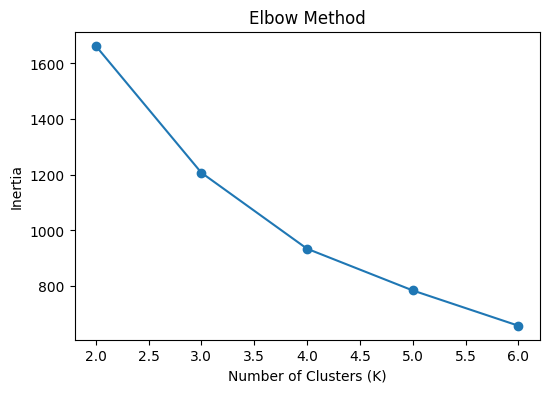


Explanation:
The Elbow Method is used to determine the optimal number of clusters.
Inertia measures how compact the clusters are (lower is better).
The optimal K is usually found at the 'elbow point' where the decrease in inertia slows down.


In [170]:
inertia = []
K_range = range(2, 7)

# Compute inertia for different values of K
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

print("\nExplanation:")
print("The Elbow Method is used to determine the optimal number of clusters.")
print("Inertia measures how compact the clusters are (lower is better).")
print("The optimal K is usually found at the 'elbow point' where the decrease in inertia slows down.")

##Cluster Validation (Silhouette Analysis)

,K,Silhouette Score
0,2,0.413423
1,3,0.406931
2,4,0.373012
3,5,0.380130
4,6,0.367727


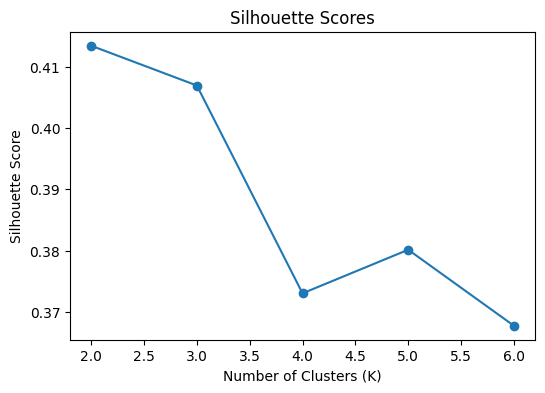

Best K based on silhouette: 2
Best silhouette score: 0.413

Explanation:
Silhouette score measures how well each data point fits within its cluster.
Values closer to 1 indicate well-separated and compact clusters.
The K with the highest silhouette score is selected as the optimal number of clusters.


In [171]:
silhouettes = []

# Compute silhouette score for each K
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouettes.append(score)

# 📊 Create table
silhouette_table = pd.DataFrame({
    "K": list(K_range),
    "Silhouette Score": silhouettes
})

display(silhouette_table)

# 📈 Plot silhouette scores
plt.figure(figsize=(6,4))
plt.plot(K_range, silhouettes, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

# ✅ Get best K
best_k = silhouette_table.loc[silhouette_table["Silhouette Score"].idxmax(), "K"]
best_score = silhouette_table["Silhouette Score"].max()

print(f"Best K based on silhouette: {best_k}")
print(f"Best silhouette score: {best_score:.3f}")

print("\nExplanation:")
print("Silhouette score measures how well each data point fits within its cluster.")
print("Values closer to 1 indicate well-separated and compact clusters.")
print("The K with the highest silhouette score is selected as the optimal number of clusters.")

##K-Means Clustering Implementation

In [172]:
# Use optimal K from silhouette analysis
K = int(best_k)

kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
customer_profile["Cluster"] = kmeans.fit_predict(X_scaled)

display(customer_profile.head())

print("\nExplanation:")
print(f"K-Means clustering was applied using K = {K}, which was selected based on the highest silhouette score.")
print("Each customer is assigned to a cluster based on similarity in spending, frequency, and recency.")


,Customer_ID,Total_Amount_log,Transaction_Count,Satisfaction_Score,Cluster
0,1,44.864024,6,10.0,0
1,2,15.584915,2,7.0,1
2,3,7.338888,1,10.0,1
3,4,16.640675,2,7.0,1
4,5,39.522616,5,8.0,1



Explanation:
K-Means clustering was applied using K = 2, which was selected based on the highest silhouette score.
Each customer is assigned to a cluster based on similarity in spending, frequency, and recency.


##Cluster Profiling and Summary

In [173]:
# Compute cluster-level averages
cluster_summary = customer_profile.groupby("Cluster")[selected_features].mean().round(2)

# Count number of customers per cluster
cluster_counts = customer_profile["Cluster"].value_counts().sort_index()

display(cluster_summary)
display(cluster_counts)

print("\nExplanation:")
print("Cluster summary shows the average behavior of customers in each cluster.")
print("Cluster counts show how many customers belong to each group.")

# Combine summary + size into one table (better for presentation)
cluster_summary_with_size = cluster_summary.copy()
cluster_summary_with_size["Cluster_Size"] = cluster_counts

print("\nCombined Cluster Summary:")
display(cluster_summary_with_size)

,Total_Amount_log,Transaction_Count,Satisfaction_Score
Cluster,,,
0,53.98,7.29,8.57
1,26.63,3.62,8.72


,count
Cluster,
0,383
1,610



Explanation:
Cluster summary shows the average behavior of customers in each cluster.
Cluster counts show how many customers belong to each group.

Combined Cluster Summary:


,Total_Amount_log,Transaction_Count,Satisfaction_Score,Cluster_Size
Cluster,,,,
0,53.98,7.29,8.57,383
1,26.63,3.62,8.72,610



##Customer Segment Naming and Interpretation

In [174]:
# Create a score to identify the highest-value cluster
cluster_score = (
    cluster_summary["Total_Amount_log"].rank(ascending=False) +
    cluster_summary["Transaction_Count"].rank(ascending=False)
)

best_cluster = cluster_score.idxmin()

cluster_names = {}

# Assign descriptive names based on number of clusters
if len(cluster_summary) == 2:
    for cl in cluster_summary.index:
        if cl == best_cluster:
            cluster_names[cl] = "High-Value Frequent Customers"
        else:
            cluster_names[cl] = "Low-Value Occasional Customers"
else:
    median_spend = cluster_summary["Total_Amount_log"].median()

    for cl in cluster_summary.index:
        if cl == best_cluster:
            cluster_names[cl] = "High-Value Frequent Customers"
        elif cluster_summary.loc[cl, "Total_Amount_log"] >= median_spend:
            cluster_names[cl] = "Moderate-Value Customers"
        else:
            cluster_names[cl] = "Low-Value Occasional Customers"

# Map descriptive names to each customer
customer_profile["Cluster_Name"] = customer_profile["Cluster"].map(cluster_names)

print("Cluster names:")
print(cluster_names)

print("\nCustomer Cluster Assignment (sample):")
display(customer_profile[["Customer_ID", "Cluster", "Cluster_Name"]].head())

# Segment summary with names
cluster_summary_named = customer_profile.groupby("Cluster_Name")[selected_features].mean().round(2)
cluster_counts_named = customer_profile["Cluster_Name"].value_counts()

segment_summary = cluster_summary_named.copy()
segment_summary["Cluster_Size"] = cluster_counts_named

print("\nSegment Summary:")
display(segment_summary)

print("\nExplanation:")
print("Cluster names were assigned based on average spending and transaction frequency.")
print("The highest-scoring cluster was labeled as High-Value Frequent Customers.")
print("Other clusters were labeled according to their relative customer behavior.")

Cluster names:
{0: 'High-Value Frequent Customers', 1: 'Low-Value Occasional Customers'}

Customer Cluster Assignment (sample):


,Customer_ID,Cluster,Cluster_Name
0,1,0,High-Value Frequent Customers
1,2,1,Low-Value Occasional Customers
2,3,1,Low-Value Occasional Customers
3,4,1,Low-Value Occasional Customers
4,5,1,Low-Value Occasional Customers



Segment Summary:


,Total_Amount_log,Transaction_Count,Satisfaction_Score,Cluster_Size
Cluster_Name,,,,
High-Value Frequent Customers,53.98,7.29,8.57,383
Low-Value Occasional Customers,26.63,3.62,8.72,610



Explanation:
Cluster names were assigned based on average spending and transaction frequency.
The highest-scoring cluster was labeled as High-Value Frequent Customers.
Other clusters were labeled according to their relative customer behavior.


##Segment-Level Summary

In [175]:
# Compute average values per segment
cluster_summary_named = customer_profile.groupby("Cluster_Name")[selected_features].mean().round(2)

# Count customers per segment
cluster_counts_named = customer_profile["Cluster_Name"].value_counts()

# Combine into one table
segment_summary = cluster_summary_named.copy()
segment_summary["Cluster_Size"] = cluster_counts_named

print("Segment Summary:")
display(segment_summary)

print("\nExplanation:")
print("This table shows the average spending, transaction frequency, and recency for each customer segment.")
print("It also shows the number of customers in each segment.")

Segment Summary:


,Total_Amount_log,Transaction_Count,Satisfaction_Score,Cluster_Size
Cluster_Name,,,,
High-Value Frequent Customers,53.98,7.29,8.57,383
Low-Value Occasional Customers,26.63,3.62,8.72,610



Explanation:
This table shows the average spending, transaction frequency, and recency for each customer segment.
It also shows the number of customers in each segment.


##Dimensionality Reduction using PCA

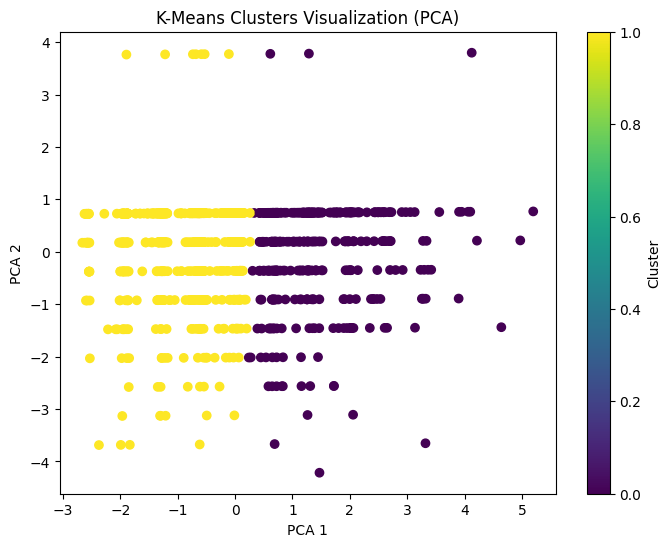

Explained variance by PCA components: [0.66  0.333]
PCA Loadings:


,PCA 1,PCA 2
Total_Amount_log,0.707,0.006
Transaction_Count,0.707,0.003
Satisfaction_Score,-0.006,1.000



Explanation:
PCA reduces the selected features into two components for easier visualization.
The scatter plot shows how customers are grouped based on their cluster assignments.
The loadings indicate how much each original feature contributes to PCA 1 and PCA 2.


In [176]:
# Apply PCA to reduce features into 2 dimensions
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

# Store PCA coordinates in the customer profile
customer_profile["PCA1"] = coords[:, 0]
customer_profile["PCA2"] = coords[:, 1]

# Plot clusters using numeric cluster labels
plt.figure(figsize=(8,6))
plt.scatter(coords[:, 0], coords[:, 1], c=customer_profile["Cluster"], cmap='viridis')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters Visualization (PCA)")
plt.colorbar(label="Cluster")
plt.show()

print("Explained variance by PCA components:", pca.explained_variance_ratio_.round(3))

loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_features,
    columns=["PCA 1", "PCA 2"]
)

print("PCA Loadings:")
display(loadings.round(3))

print("\nExplanation:")
print("PCA reduces the selected features into two components for easier visualization.")
print("The scatter plot shows how customers are grouped based on their cluster assignments.")
print("The loadings indicate how much each original feature contributes to PCA 1 and PCA 2.")

##Customer Segments Visualization (PCA with Labels)

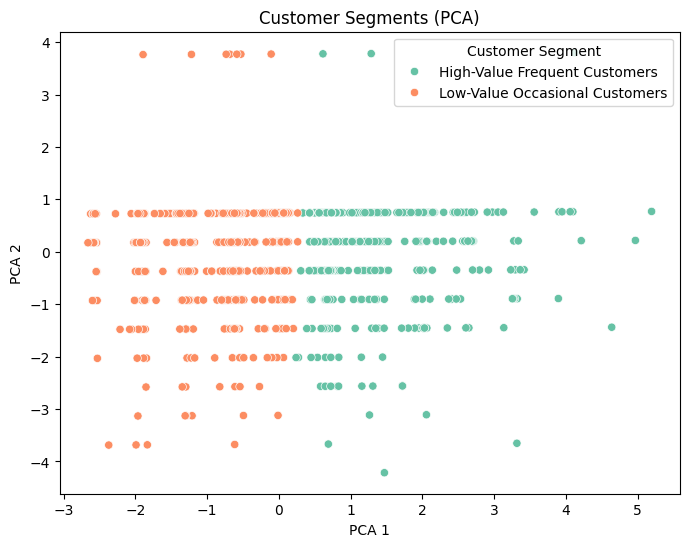


Explanation:
This plot shows customer segments after dimensionality reduction using PCA.
Each point represents a customer, and colors indicate their assigned segment.
The separation between groups reflects how distinct the customer segments are.


In [177]:
# Ensure PCA values are already added
customer_profile["PCA1"] = coords[:, 0]
customer_profile["PCA2"] = coords[:, 1]

# Plot using cluster names (more interpretable)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=customer_profile,
    x="PCA1",
    y="PCA2",
    hue="Cluster_Name",
    palette="Set2"
)

plt.title("Customer Segments (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Customer Segment")
plt.show()

print("\nExplanation:")
print("This plot shows customer segments after dimensionality reduction using PCA.")
print("Each point represents a customer, and colors indicate their assigned segment.")
print("The separation between groups reflects how distinct the customer segments are.")

##Feature Correlation Analysis

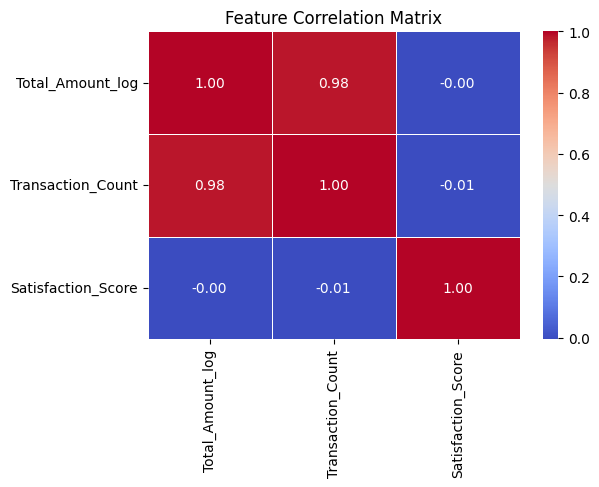


Explanation:
This heatmap shows the correlation between selected features.
Values closer to 1 or -1 indicate strong relationships, while values near 0 indicate weak relationships.
Understanding correlations helps identify redundancy and relationships between variables.


In [178]:
# Compute correlation matrix
corr_matrix = customer_profile[selected_features].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()

print("\nExplanation:")
print("This heatmap shows the correlation between selected features.")
print("Values closer to 1 or -1 indicate strong relationships, while values near 0 indicate weak relationships.")
print("Understanding correlations helps identify redundancy and relationships between variables.")

##Customer Segment Insights

In [179]:
print("Customer Segment Descriptions:")

for cl, name in cluster_names.items():
    spend = cluster_summary.loc[cl, "Total_Amount_log"]
    freq = cluster_summary.loc[cl, "Transaction_Count"]
    size = cluster_counts[cl]

    description = f"{name}: "

    if name == "High-Value Frequent Customers":
        description += (
            f"These customers have the highest spending (avg = {spend:.2f}) "
            f"and purchase most frequently (avg = {freq:.2f}). "
            "They represent the most valuable segment and are likely loyal customers."
        )
    elif name == "Moderate-Value Customers":
        description += (
            f"These customers have moderate spending (avg = {spend:.2f}) "
            f"and purchase frequency (avg = {freq:.2f}). "
            "They have potential for upselling and retention strategies."
        )
    else:
        description += (
            f"These customers have lower spending (avg = {spend:.2f}) "
            f"and fewer transactions (avg = {freq:.2f}). "
            "They may require promotions or engagement strategies to increase activity."
        )

    description += f" Cluster size = {size}."
    print("-", description)

Customer Segment Descriptions:
- High-Value Frequent Customers: These customers have the highest spending (avg = 53.98) and purchase most frequently (avg = 7.29). They represent the most valuable segment and are likely loyal customers. Cluster size = 383.
- Low-Value Occasional Customers: These customers have lower spending (avg = 26.63) and fewer transactions (avg = 3.62). They may require promotions or engagement strategies to increase activity. Cluster size = 610.


##Summary

In [180]:
summary = cluster_summary.copy()

lines = []

for cl in summary.index:
    line = (
        f"Cluster {cl}: "
        f"Avg Spend = {summary.loc[cl, 'Total_Amount_log']:.2f}, "
        f"Avg Transactions = {summary.loc[cl, 'Transaction_Count']:.2f}, "
        f"Cluster Size = {cluster_counts[cl]}"
    )
    lines.append(line)

print("Cluster Summary Notes:")
for l in lines:
    print("-", l)

Cluster Summary Notes:
- Cluster 0: Avg Spend = 53.98, Avg Transactions = 7.29, Cluster Size = 383
- Cluster 1: Avg Spend = 26.63, Avg Transactions = 3.62, Cluster Size = 610


In [181]:
"""##Export Final Results"""

customer_profile.to_csv("FinMark_Final_Clustered_Output.csv", index=False)
print("Saved as FinMark_Final_Clustered_Output.csv")

Saved as FinMark_Final_Clustered_Output.csv
